In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential 
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

tf.random.set_seed(1234)

In [3]:
X = np.load('./dataset/handsignX.npy')
y = np.load('./dataset/handsigny.npy')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")




X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_cv: {X_cv.shape}")
print(f"Shape of y_test: {y_cv.shape}")



m,n = X.shape


# np.imshow(X)

Shape of X: (5000, 400)
Shape of y: (5000, 1)
Shape of X_train: (4000, 400)
Shape of y_train: (4000, 1)
Shape of X_cv: (1000, 400)
Shape of y_test: (1000, 1)


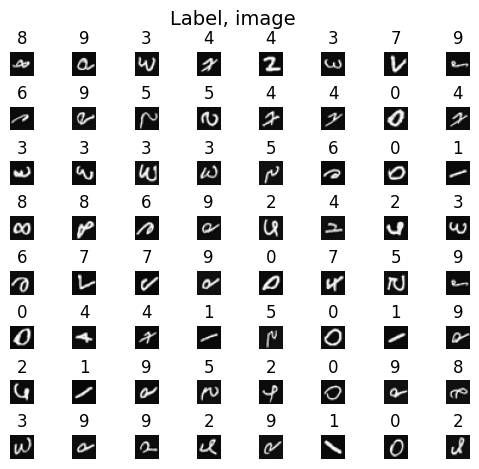

In [4]:
fig,axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i,ax in enumerate(axes.flat):
    rand_idx = np.random.randint(m)
    X_reshaped = X[rand_idx].reshape(20,20)
    ax.imshow(X_reshaped, cmap='grey')
    ax.set_title(y[rand_idx,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)



In [37]:


def nn_model(X_train, y_train, X_cv, y_cv, l_rate, regularizer, epoch):

    model = Sequential([
        Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(regularizer)),
        Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(regularizer)),
        Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(regularizer))
    ])

    # model.summary()
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(l_rate),
        metrics=['accuracy']
    )

    model.fit(X_train,y_train, epochs=epoch)
    print('\n')

    train_loss, train_acc = model.evaluate(X_train, y_train)
    cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
    print(f"Train Accuracy: {train_acc*100:.2f}")
    print(f"CV Accuracy: {cv_acc*100:.2f}")


In [39]:

regularizer = [0.01, 0.001,0.0001,0.0005]


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.01)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.01))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7820 - loss: 1.5086
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8397 - loss: 1.0961
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8472 - loss: 1.0573
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8508 - loss: 1.0380
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8568 - loss: 1.0133
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.9995
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8608 - loss: 0.9823
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.9727
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8640 - loss: 0.9657
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8660 - loss: 0.9612
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8670 - loss: 0.9547
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [52]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7995 - loss: 0.9356
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9183 - loss: 0.4861
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9392 - loss: 0.4129
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9528 - loss: 0.3672
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9645 - loss: 0.3363
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9710 - loss: 0.3136
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9760 - loss: 0.2953
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9808 - loss: 0.2814
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9835 - loss: 0.2680
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9862 - loss: 0.2562
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9877 - loss: 0.2476
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accura

In [41]:


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8235 - loss: 0.6027
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9262 - loss: 0.2948
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9480 - loss: 0.2327
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9545 - loss: 0.2270
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9582 - loss: 0.2177
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9520 - loss: 0.2408
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9682 - loss: 0.2069
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9672 - loss: 0.2168
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9750 - loss: 0.1992
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9597 - loss: 0.2518
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9747 - loss: 0.2169
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [53]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0005)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0005)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0005))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7585 - loss: 1.0492
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9120 - loss: 0.4415
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9345 - loss: 0.3571
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9523 - loss: 0.3090
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9635 - loss: 0.2762
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9712 - loss: 0.2522
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9778 - loss: 0.2331
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9810 - loss: 0.2174
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9852 - loss: 0.2045
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9875 - loss: 0.1938
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.1850
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

### 
*  Train Accuracy: 98.43%

*  CV Accuracy: 94.00%

*  The Gap: Just 4.43%